In [1]:
# import os
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [1]:
!git clone https://github.com/Bigajka/WizjaKomputerowa-Segmentacja-Skory

Cloning into 'WizjaKomputerowa-Segmentacja-Skory'...
remote: Enumerating objects: 8060, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 8060 (delta 21), reused 10 (delta 0), pack-reused 8001 (from 3)
Receiving objects: 100% (8060/8060), 1.72 GiB | 38.78 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (8023/8023), done.


In [2]:
!pip install torch torchvision albumentations opencv-python matplotlib tqdm

In [3]:
""" Download model if want to have trained """
!gdown 1kK56O5OPjPBt6fZn1Oas9Nkz7alSo23i

Downloading...
From (original): https://drive.google.com/uc?id=1kK56O5OPjPBt6fZn1Oas9Nkz7alSo23i
From (redirected): https://drive.google.com/uc?id=1kK56O5OPjPBt6fZn1Oas9Nkz7alSo23i&confirm=t&uuid=b6741009-99ec-444c-895d-2df9c08722bb
To: /content/deeplabv3_best.pth
100% 245M/245M [00:03<00:00, 64.9MB/s] 


In [15]:
""" Imports """
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
from torch.utils.data import DataLoader
import csv
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pathlib import Path
from tqdm import tqdm

In [5]:
""" Config """
NUM_CLASSES = 2
LOG_FILE = "training_log.csv"
MODEL_TYPE = "deeplabv3_resnet101"
# MODEL_TYPE = "deeplabv3_resnet50"

In [6]:
""" Prepare datas """

def move_files(src_dir, dst_dir):
    for filename in os.listdir(src_dir):
        shutil.move(os.path.join(src_dir, filename), dst_dir)

""" Merge to one folder """
src_images_dir = "/content/WizjaKomputerowa-Segmentacja-Skory/dataset_final/002/images"
dst_images_dir = "/content/WizjaKomputerowa-Segmentacja-Skory/dataset_final/001/images"
move_files(src_images_dir, dst_images_dir)

src_masks_dir = "/content/WizjaKomputerowa-Segmentacja-Skory/dataset_final/002/masks"
dst_masks_dir = "/content/WizjaKomputerowa-Segmentacja-Skory/dataset_final/001/masks"
move_files(src_masks_dir, dst_masks_dir)


""" Prepare folders with datasets"""
train_img_dir = "/content/datasets/train"
valid_img_dir = "/content/datasets/valid"
test_img_dir = "/content/datasets/test"
Path(train_img_dir + "/images").mkdir(parents=True, exist_ok=True)
Path(valid_img_dir + "/images").mkdir(parents=True, exist_ok=True)
Path(test_img_dir + "/images").mkdir(parents=True, exist_ok=True)
Path(train_img_dir + "/masks").mkdir(parents=True, exist_ok=True)
Path(valid_img_dir + "/masks").mkdir(parents=True, exist_ok=True)
Path(test_img_dir + "/masks").mkdir(parents=True, exist_ok=True)

train_img_count = 2800 # 70 %
valid_img_count = 600  # 15 %
test_img_count = 600   # 15 %

images_list = os.listdir(dst_images_dir)
masks_list = os.listdir(dst_masks_dir)

images_list.sort()
masks_list.sort()

for i in range(train_img_count):
    shutil.move(os.path.join(dst_images_dir, images_list[i]), train_img_dir + "/images")
    shutil.move(os.path.join(dst_masks_dir, masks_list[i]), train_img_dir + "/masks")

for i in range(train_img_count, train_img_count + valid_img_count, 1):
    shutil.move(os.path.join(dst_images_dir, images_list[i]), valid_img_dir + "/images")
    shutil.move(os.path.join(dst_masks_dir, masks_list[i]), valid_img_dir + "/masks")

for i in range(train_img_count + valid_img_count, train_img_count + valid_img_count + test_img_count, 1):
    shutil.move(os.path.join(dst_images_dir, images_list[i]), test_img_dir + "/images")
    shutil.move(os.path.join(dst_masks_dir, masks_list[i]), test_img_dir + "/masks")

In [7]:
""" Prepare device """

if torch.cuda.is_available():
    print("Using GPU")
    print("GPU Info:")
    print(torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")

Using GPU
GPU Info:
Tesla T4
VRAM: 15.6 GB


In [18]:
""" Prepare dataloaders """
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = os.path.splitext(img_name)[0] + ".png"

        image = np.array(Image.open(os.path.join(self.images_dir, img_name)).convert("RGB"))
        mask  = np.array(Image.open(os.path.join(self.masks_dir,  mask_name)).convert("L"))
        mask = np.clip(mask, 0, NUM_CLASSES - 1)  # utnij wszystko powyżej zakresu

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        return image, mask.long()

train_transform = A.Compose([
    A.RandomResizedCrop([512, 512]),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# DataLoadery
train_ds = SegmentationDataset(Path(train_img_dir + "/images"), Path(train_img_dir + "/masks"), train_transform)
val_ds   = SegmentationDataset(Path(valid_img_dir + "/images"), Path(valid_img_dir + "/masks"), val_transform)
test_ds  = SegmentationDataset(Path(test_img_dir + "/images"),  Path(test_img_dir + "/masks"),  test_transform)

_loader_kwargs = dict(num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, **_loader_kwargs)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [9]:
""" Prepare model """
if MODEL_TYPE == "deeplabv3_resnet101":
    from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
    model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT)
elif MODEL_TYPE == "deeplabv3_resnet50":
    from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
    model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
else:
    raise ValueError(f"Unsupported model type: {MODEL_TYPE}")

print(f"Model {MODEL_TYPE} loaded with pretrained weights.")

model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

model = model.to(device)
model = torch.compile(model)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 170MB/s] 


Model deeplabv3_resnet101 loaded with pretrained weights.


In [ ]:
""" Training loop """

# Optymalizator i loss
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=50)
criterion = nn.CrossEntropyLoss(ignore_index=255)
scaler    = torch.amp.GradScaler('cuda')

history = []
best_iou = 0.0

# Header CSV
with open(LOG_FILE, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "iou", "dice", "precision", "recall", "accuracy", "saved_model"])
    writer.writeheader()

NUM_EPOCHS = 50  

# Pętla treningowa
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):  # ← obliczenia w float16
            output = model(images)
            # DeepLab zwraca słownik z 'out' i 'aux'
            loss = criterion(output["out"], masks) + 0.4 * criterion(output["aux"], masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)

    # ---------- EWALUACJA ----------
    model.eval()
    total_tp = total_fp = total_fn = total_tn = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            with torch.amp.autocast('cuda'):
                output = model(images)["out"]

            probs = torch.softmax(output.float(), dim=1)[:, 1]
            preds = (probs > 0.5).long()

            total_tp += ((preds == 1) & (masks == 1)).sum().item()
            total_fp += ((preds == 1) & (masks == 0)).sum().item()
            total_fn += ((preds == 0) & (masks == 1)).sum().item()
            total_tn += ((preds == 0) & (masks == 0)).sum().item()

    eps = 1e-8
    precision = total_tp / (total_tp + total_fp + eps)
    recall    = total_tp / (total_tp + total_fn + eps)
    dice      = 2 * total_tp / (2 * total_tp + total_fp + total_fn + eps)
    iou       = total_tp / (total_tp + total_fp + total_fn + eps)
    accuracy  = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn + eps)

    # ---------- WYPISZ ----------
    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
          f"IoU: {iou:.4f} | Dice: {dice:.4f} | "
          f"Prec: {precision:.4f} | Rec: {recall:.4f} | Acc: {accuracy:.4f}")

    # ---------- ZAPISZ HISTORIĘ ----------
    row = {
        "epoch": epoch+1, 
        "train_loss": round(avg_loss, 6),
        "iou": round(iou, 6), 
        "dice": round(dice, 6),
        "precision": round(precision, 6), 
        "recall": round(recall, 6),
        "accuracy": round(accuracy, 6),
        "saved_model": "Yes" if iou > best_iou else "No"
        }
    history.append(row)

    with open(LOG_FILE, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=row.keys()).writerow(row)

    # ---------- ZAPISZ NAJLEPSZY MODEL ----------
    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), "deeplabv3_best.pth")
        print(f"           → Nowy najlepszy model zapisany (IoU: {best_iou:.4f})")

print(f"\nTrening zakończony. Najlepsze IoU: {best_iou:.4f}")

# torch.save(model.state_dict(), "deeplabv3_custom_epoch.pth")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
W0523 19:29:28.441000 512 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slown

Epoch  1/50 | Loss: 0.2688 | IoU: 0.8431 | Dice: 0.9149 | Prec: 0.9174 | Rec: 0.9123 | Acc: 0.9666
           → Nowy najlepszy model zapisany (IoU: 0.8431)
Epoch  2/50 | Loss: 0.1649 | IoU: 0.8663 | Dice: 0.9284 | Prec: 0.9282 | Rec: 0.9285 | Acc: 0.9718
           → Nowy najlepszy model zapisany (IoU: 0.8663)
Epoch  3/50 | Loss: 0.1506 | IoU: 0.8591 | Dice: 0.9242 | Prec: 0.9087 | Rec: 0.9403 | Acc: 0.9697
Epoch  4/50 | Loss: 0.1435 | IoU: 0.8737 | Dice: 0.9326 | Prec: 0.9361 | Rec: 0.9291 | Acc: 0.9736
           → Nowy najlepszy model zapisany (IoU: 0.8737)
Epoch  5/50 | Loss: 0.1261 | IoU: 0.8658 | Dice: 0.9281 | Prec: 0.9291 | Rec: 0.9270 | Acc: 0.9718
Epoch  6/50 | Loss: 0.1244 | IoU: 0.8798 | Dice: 0.9361 | Prec: 0.9252 | Rec: 0.9472 | Acc: 0.9746
           → Nowy najlepszy model zapisany (IoU: 0.8798)
Epoch  7/50 | Loss: 0.1229 | IoU: 0.8785 | Dice: 0.9353 | Prec: 0.9517 | Rec: 0.9194 | Acc: 0.9750
Epoch  8/50 | Loss: 0.1275 | IoU: 0.8824 | Dice: 0.9375 | Prec: 0.9233 | Rec: 0

In [ ]:
# import os
# import numpy as np
# from PIL import Image

# masks_dir = "/content/WizjaKomputerowa-Segmentacja-Skory/dataset_final/001/masks"

# for fname in os.listdir(masks_dir):
#     mask = np.array(Image.open(os.path.join(masks_dir, fname)))
#     unique_vals = np.unique(mask)
#     max_val = mask.max()

#     if max_val >= 2:
#         print(f"PROBLEM: {fname} | wartości: {unique_vals} | max: {max_val}")

# print("Gotowe!")

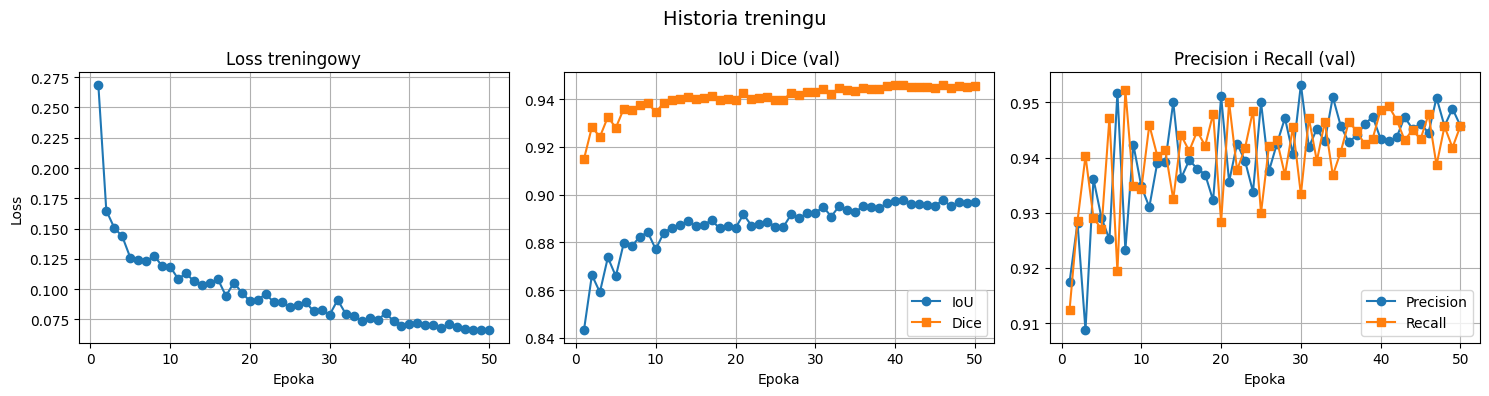

In [ ]:
""" Plot training history """
log = pd.read_csv("training_log.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(log["epoch"], log["train_loss"], marker="o")
axes[0].set_title("Loss treningowy")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(log["epoch"], log["iou"],  marker="o", label="IoU")
axes[1].plot(log["epoch"], log["dice"], marker="s", label="Dice")
axes[1].set_title("IoU i Dice (val)")
axes[1].set_xlabel("Epoka")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(log["epoch"], log["precision"], marker="o", label="Precision")
axes[2].plot(log["epoch"], log["recall"],    marker="s", label="Recall")
axes[2].set_title("Precision i Recall (val)")
axes[2].set_xlabel("Epoka")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Historia treningu", fontsize=14)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

In [20]:
def evaluate(model, loader, device, threshold=0.5):
    """
    Metryka   | Słaby model | Dobry model | Świetny model
    IoU       |   < 0.60    |  0.75-0.85  |    > 0.90
    Dice      |   < 0.75    |  0.85-0.92  |    > 0.95
    Precision |   < 0.70    |  0.85-0.92  |    > 0.95
    Recall    |   < 0.70    |  0.85-0.92  |    > 0.95
    """
    model.eval()
    total_tp = total_fp = total_fn = total_tn = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Ewaluacja"):  # ← pasek postępu
            images = images.to(device)
            masks = masks.to(device)

            with torch.amp.autocast('cuda'):  # ← obliczenia w float16, tak jak w treningu
                output = model(images)["out"]

            probs = torch.softmax(output.float(), dim=1)[:, 1]  # .float() bo softmax na float16 może być niedokładny
            preds = (probs > threshold).long()

            total_tp += ((preds == 1) & (masks == 1)).sum().item()
            total_fp += ((preds == 1) & (masks == 0)).sum().item()
            total_fn += ((preds == 0) & (masks == 1)).sum().item()
            total_tn += ((preds == 0) & (masks == 0)).sum().item()

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall    = total_tp / (total_tp + total_fn + 1e-8)
    dice      = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-8)
    iou       = total_tp / (total_tp + total_fp + total_fn + 1e-8)
    accuracy  = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn + 1e-8)

    print(f"IoU (Jaccard):  {iou:.4f}  {'✓' if iou > 0.75 else '✗'}")
    print(f"Dice / F1:      {dice:.4f}  {'✓' if dice > 0.85 else '✗'}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"Accuracy:       {accuracy:.4f}")

    return {"iou": iou, "dice": dice, "precision": precision,
            "recall": recall, "accuracy": accuracy}

In [21]:
def show_predictions(model, dataset, device, n=4):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))

    for i in range(n):
        image, mask = dataset[i]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))["out"]
            pred = torch.softmax(output, dim=1)[0, 1].cpu().numpy()

        # denormalizacja do wyświetlenia
        img_display = image.permute(1, 2, 0).numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) \
                                  + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title("Oryginał")
        axes[i, 1].imshow(mask.numpy(), cmap="gray")
        axes[i, 1].set_title("Prawdziwa maska")
        axes[i, 2].imshow(pred, cmap="hot")
        axes[i, 2].set_title("Predykcja (ciepło = skóra)")

        for ax in axes[i]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [23]:
def predict(model, image_path, device, threshold=0.5):
    image = np.array(Image.open(image_path).convert("RGB"))
    original_h, original_w = image.shape[:2]

    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    tensor = transform(image=image)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(tensor)["out"]

    probs = torch.softmax(output.float(), dim=1)[0, 1].cpu().numpy()
    mask = (probs > threshold).astype(np.uint8) * 255
    mask = np.array(Image.fromarray(mask).resize((original_w, original_h), Image.NEAREST))

    return mask, probs

def save_mask(mask, output_path):
    Image.fromarray(mask).save(output_path)
    print(f"Maska zapisana: {output_path}")


def visualize(image_path, mask):
    original = np.array(Image.open(image_path).convert("RGB"))
    overlay = original.copy()
    overlay[mask == 0] = (overlay[mask == 0] * 0.3).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original);  axes[0].set_title("Oryginał")
    axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Maska (biały = skóra)")
    axes[2].imshow(overlay);   axes[2].set_title("Nałożona maska")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def predict_single(model, image_path, device, output_path=None, threshold=0.5, show=True):
    mask, probs = predict(model, image_path, device, threshold)
    if output_path:
        save_mask(mask, output_path)
    if show:
        visualize(image_path, mask)
    return mask, probs


def predict_batch(model, input_dir, output_dir, device, threshold=0.5):
    os.makedirs(output_dir, exist_ok=True)
    files = [f for f in os.listdir(input_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    for fname in files:
        mask, _ = predict(model, os.path.join(input_dir, fname), device)
        out_name = os.path.splitext(fname)[0] + "_maska.png"
        save_mask(mask, os.path.join(output_dir, out_name))

    print(f"Gotowe! Przetworzono {len(files)} zdjęć.")

In [ ]:
""" After training on validation set: """
metrics = evaluate(model, val_loader, device)
show_predictions(model, val_ds, device)

=== WYNIKI NA ZBIORZE TESTOWYM ===


Ewaluacja: 100%|██████████| 75/75 [00:16<00:00,  4.61it/s]


IoU (Jaccard):  0.8863  ✓
Dice / F1:      0.9397  ✓
Precision:      0.9257
Recall:         0.9541
Accuracy:       0.9780


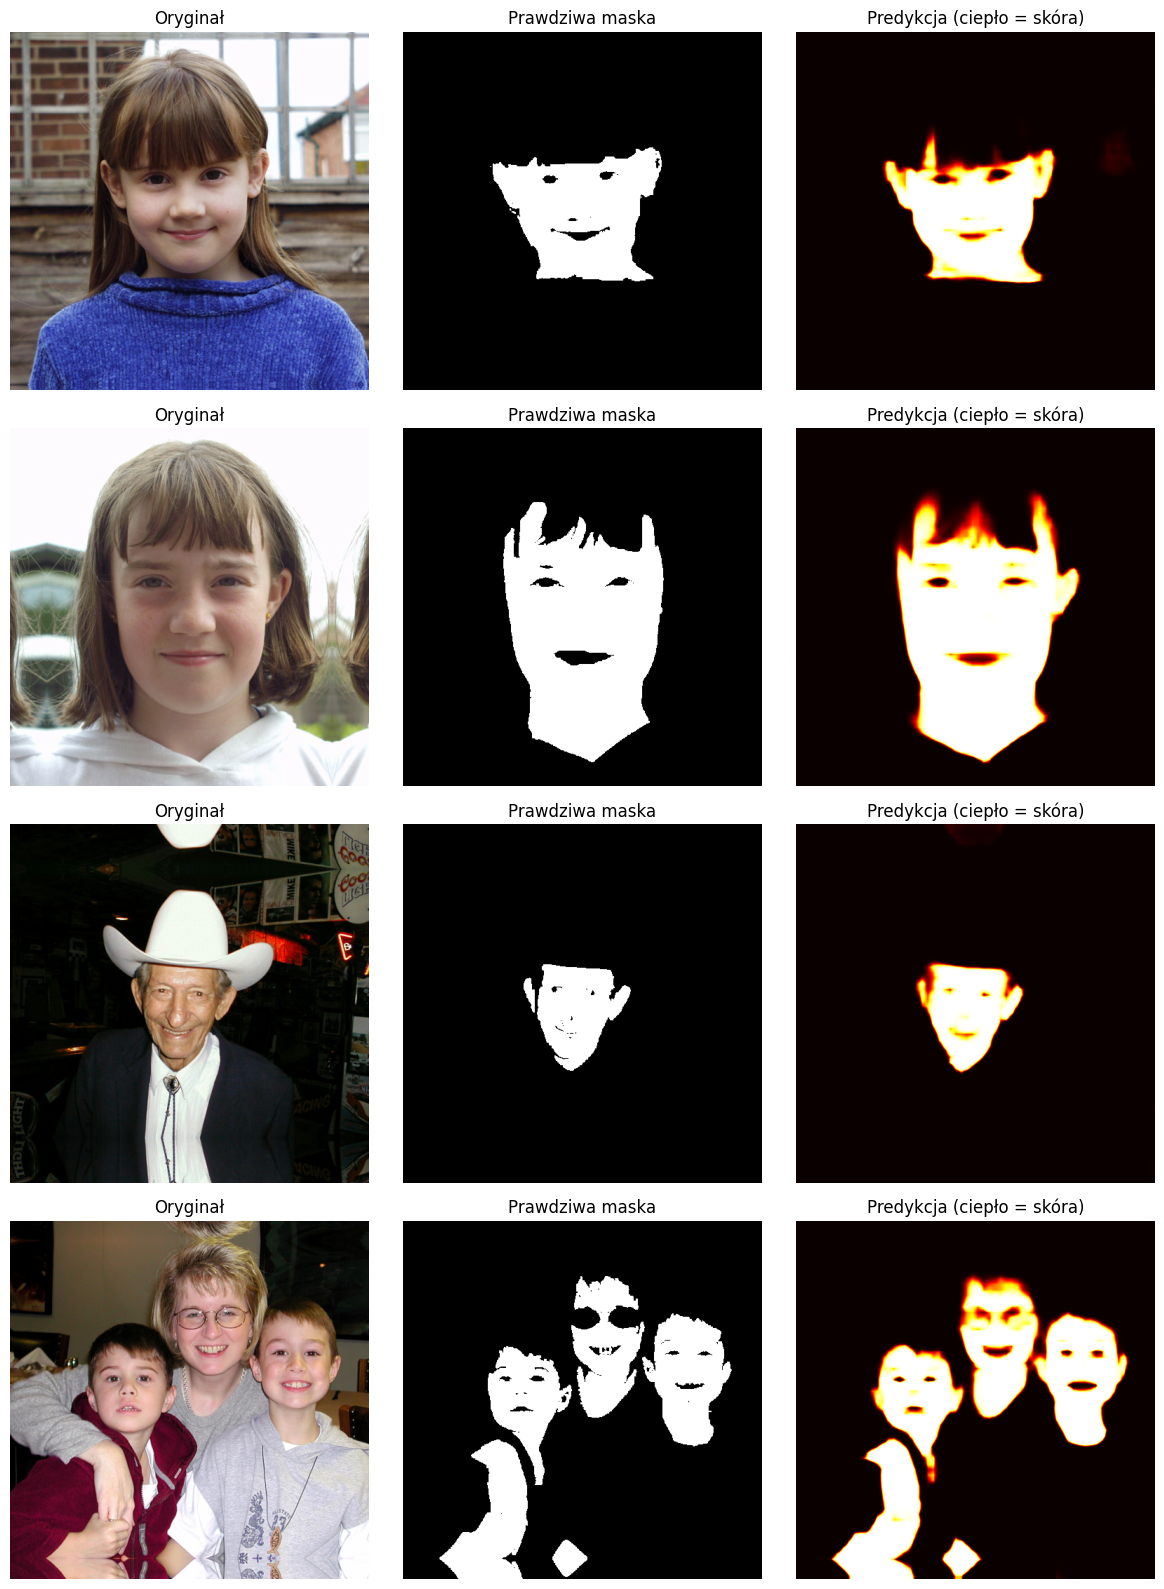

In [22]:
# Wczytaj najlepszy model i przetestuj na zbiorze testowym
model.load_state_dict(torch.load("deeplabv3_best.pth", map_location=device))
model.eval()  # ← bez tego wyniki będą losowo gorsze

print("=== WYNIKI NA ZBIORZE TESTOWYM ===")
test_metrics = evaluate(model, test_loader, device)

# ← warto też zobaczyć predykcje wizualnie
show_predictions(model, test_ds, device, n=4)

Maska zapisana: /content/custom_img/goddamn_mask.png


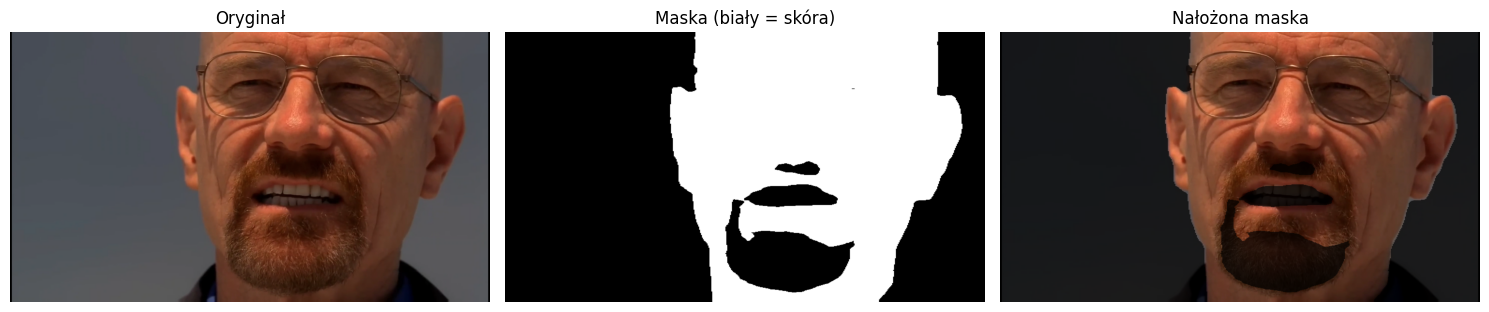

Maska zapisana: /content/custom_img/korwinel_mask.png


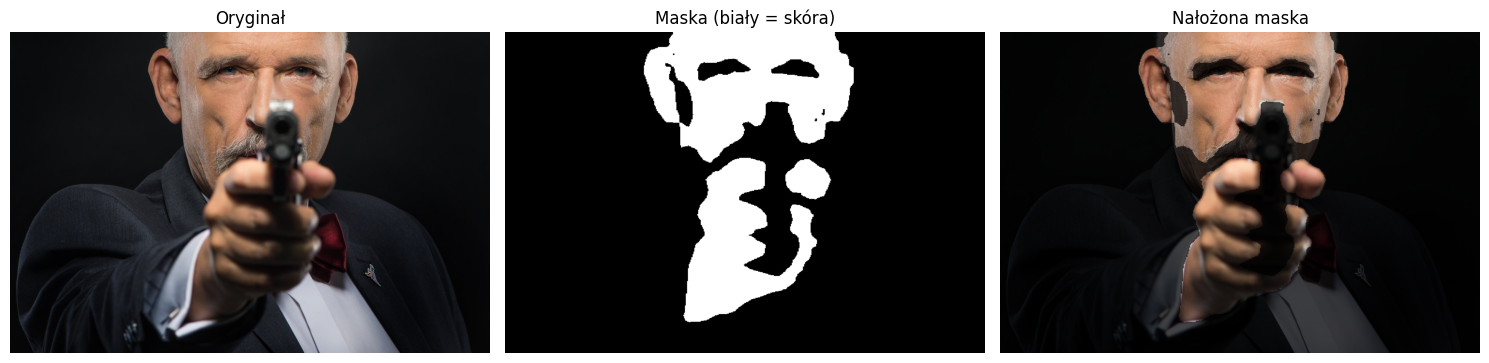

Maska zapisana: /content/custom_img/wyjazd_mask.png


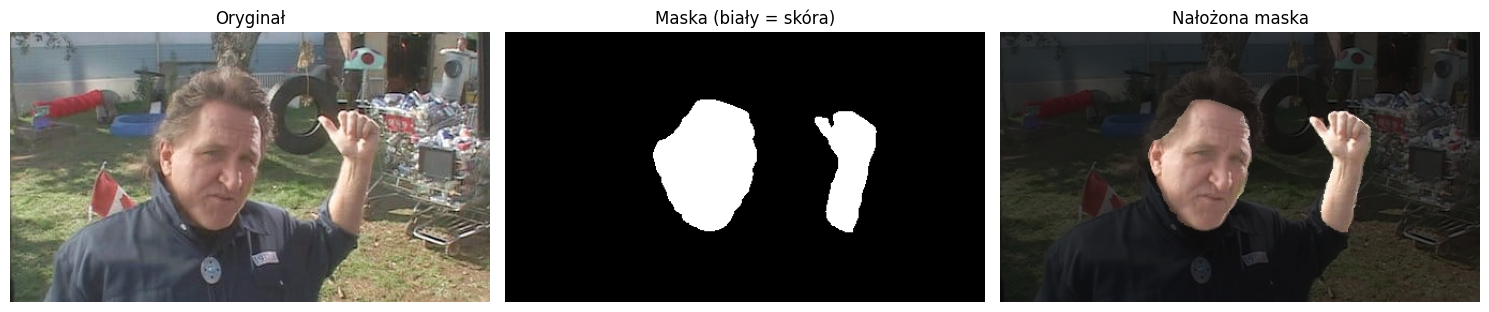

In [24]:
""" Create masks for custom images """

custom_images_dir = "/content/custom_img"
custom_images = [
    "goddamn.png",
    "korwinel.jpg",
    "wyjazd.jpg"
]

for img in custom_images:
    mask, probs = predict_single(
        model,
        image_path=os.path.join(custom_images_dir, img),
        device=device,
        output_path=os.path.join(custom_images_dir, img.split('.')[0] + '_mask.png'),  # None = nie zapisuj
        show=True,                # False = nie pokazuj wykresu
    )

